# Define paths

In [1]:
# To run this model notebook, first run Elias_create_train_val_test_datasets.ipynb to create the datasets, then copy the printed paths and paste them below

train_data_dir = '/Users/et/code/Lucia-Cordero/ReefSight-Project/raw_data/image_data/train_validation_test/train'
val_data_dir = '/Users/et/code/Lucia-Cordero/ReefSight-Project/raw_data/image_data/train_validation_test/val'
test_data_dir = '/Users/et/code/Lucia-Cordero/ReefSight-Project/raw_data/image_data/train_validation_test/test'

# Additionally, define path to save model
model_path = '/Users/et/code/Lucia-Cordero/ReefSight-Project/models'

# VGG19 model

In [2]:
# Load data using image_dataset_from_directory
from tensorflow.keras.utils import image_dataset_from_directory

batch_size = 16
seed = 42
image_size = (224, 224)

# Load datasets
train_ds = image_dataset_from_directory(
    train_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    val_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

test_ds = image_dataset_from_directory(
    test_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

print("Class names train dataset:", train_ds.class_names)
print("Class names validation dataset:", val_ds.class_names)
print("Class names test dataset:", test_ds.class_names)

Found 540 files belonging to 2 classes.
Found 179 files belonging to 2 classes.
Found 182 files belonging to 2 classes.
Class names train dataset: ['Bleached', 'Unbleached']
Class names validation dataset: ['Bleached', 'Unbleached']
Class names test dataset: ['Bleached', 'Unbleached']


In [3]:
# Built and compile advanced CNN model

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG19

# Constants
image_size = (224, 224)
input_shape = image_size + (3,)
num_classes = 2
learning_rate = 0.003

def create_vgg19_model(input_shape, num_classes=2, learning_rate=0.001):
    # Build the model
    model = models.Sequential()

    # Add a data augmentation layer
    model.add(layers.RandomFlip("horizontal_and_vertical", input_shape=input_shape))
    model.add(layers.RandomRotation(0.2))
    model.add(layers.RandomZoom(0.2))
    model.add(layers.RandomBrightness(0.2))
    model.add(layers.RandomContrast(0.2))
    model.add(layers.GaussianNoise(0.1))

    # Normalize pixel values to [0,1] inside the model so saved model includes preprocessing
    model.add(layers.Rescaling(1./255, input_shape=input_shape))

    # Load VGG19 without the top layers (classifier) and with pre-trained weights
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)

    # Unfreeze the last few layers for fine-tuning
    for layer in base_model.layers[-3:]:  # Unfreeze the last 3 layers
        layer.trainable = True

    # Optionally, keep the rest of the base model frozen
    for layer in base_model.layers[:-3]:
        layer.trainable = False

    # Add the base model
    model.add(base_model)

    # Add MaxPooling Layer
    #model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.GlobalAveragePooling2D())# Use Global Average Pooling instead of MaxPooling, which is more common with VGG19

    # Flatten the output
    #model.add(layers.Flatten()) # not necessary when GlobalAveragePooling2D is used

    # Fully connected layers
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    # Output layer
    model.add(layers.Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

    # Compile the model
    adam = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=adam, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Create and display the model summary
vgg19_model = create_vgg19_model(input_shape, num_classes, learning_rate)
vgg19_model.summary()

/Users/et/.pyenv/versions/3.10.6/envs/ReefSight-Project/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,156,993 (76.89 MB)

 Trainable params: 4,851,713 (18.51 MB)

 Non-trainable params: 15,305,280 (58.39 MB)

In [4]:
# Train the VGG19 model using tf.data `train_ds` and `val_ds`

import os

# Configure callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                     patience=10,
                                     restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(os.path.join(model_path, 'VGG19_image_model.keras'),
                                       monitor='val_accuracy',
                                       save_best_only=True), # What does ModelCheckpoint do?
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy',
                                         factor=0.5,
                                         patience=2,
                                         verbose=1), # What does ReduceLROnPlateau do?
]

# Train using datasets
epochs = 1000

history = vgg19_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks,
)

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6500 - loss: 0.7091 - val_accuracy: 0.4693 - val_loss: 6.9108 - learning_rate: 0.0030
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.7130 - loss: 0.5877 - val_accuracy: 0.4804 - val_loss: 2.6766 - learning_rate: 0.0030
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.7426 - loss: 0.5482 - val_accuracy: 0.4804 - val_loss: 2.9977 - learning_rate: 0.0030
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7259 - loss: 0.5338 - val_accuracy: 0.4916 - val_loss: 2.4821 - learning_rate: 0.0030
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7611 - loss: 0.5164 - val_accuracy: 0.6592 - val_loss: 0.9068 - learning_rate: 0.0030
Epoch 6/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7537 - loss: 0.5192 - val_accuracy: 0.5698 - val_loss: 1.4722 - learning_rate: 0.0030
Epoch 7/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7528 - loss: 0.4764
Epo

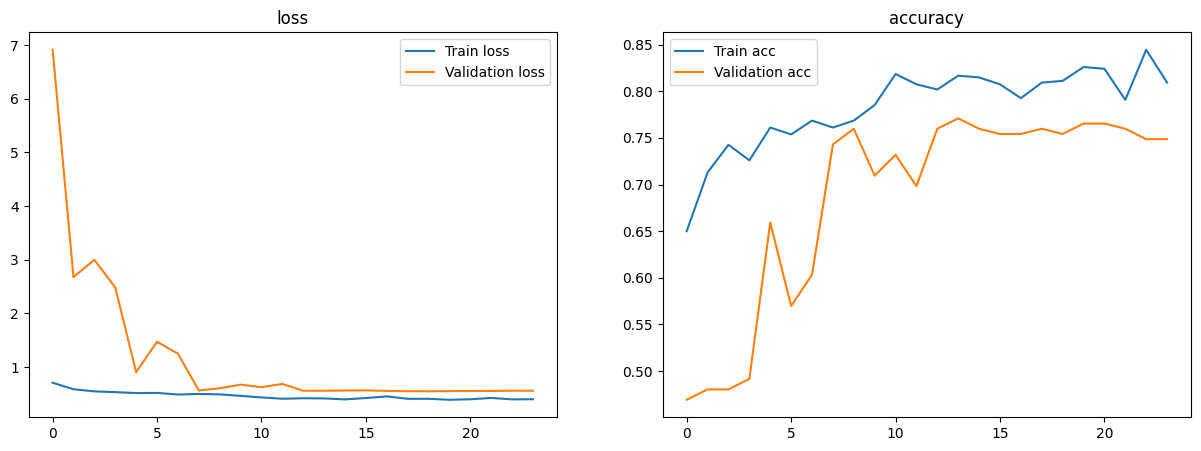

In [5]:
import matplotlib.pyplot as plt

# Plot training history

def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].set_title('loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
    ax[1].set_title('accuracy')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation acc")
    ax[0].legend()
    ax[1].legend()

plot_history(history)

In [6]:
# Evaluate the model on the val dataset

test_loss, test_accuracy = vgg19_model.evaluate(val_ds)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


# Evaluate the model on the test dataset

test_loss, test_accuracy = vgg19_model.evaluate(test_ds)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7709 - loss: 0.5596
Test Loss: 0.5596201419830322
Test Accuracy: 0.7709497213363647
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7912 - loss: 0.5016
Test Loss: 0.5016000866889954
Test Accuracy: 0.791208803653717


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step


2025-12-14 15:55:00.160807: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


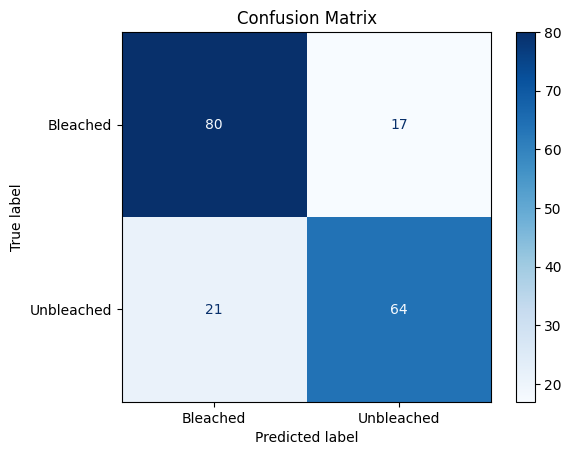

In [7]:
# Plot confusion matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

# Iterate through the test dataset to collect predictions
for images, labels in test_ds:
    y_true.extend(labels)  # Assuming labels are already in a format compatible with y_true
    predictions = vgg19_model.predict(images)
    # For binary classification, use a threshold of 0.5 to determine class
    predicted_class = (predictions > 0.5).astype(int)  # Convert probabilities to class labels
    y_pred.extend(predicted_class)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_ds.class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Load a model

In [8]:
model_loaded = tf.keras.models.load_model(os.path.join('/Users/et/code/Lucia-Cordero/ReefSight-Project/models', 'VGG19_image_model.keras'))
model_loaded.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,860,421 (113.91 MB)

 Trainable params: 4,851,713 (18.51 MB)

 Non-trainable params: 15,305,280 (58.39 MB)

 Optimizer params: 9,703,428 (37.02 MB)

# Predictions

Randomly selected image: 33588598730_187e4e0abb_o.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Probability Unbleached: 0.40621528029441833
Probability Bleached: 0.5937846899032593
Predicted class index: 0
Class names test dataset: ['Bleached', 'Unbleached']
Predicted class: Bleached


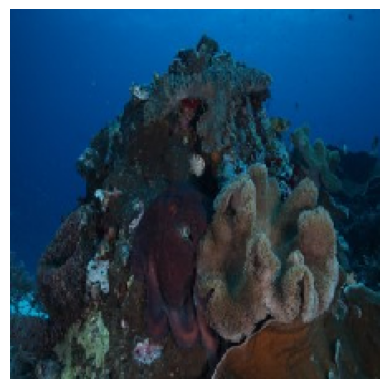

In [9]:
# Make predictions on a single image from the test dataset
from tensorflow.keras.preprocessing import image
import random

# List all files in the directory
image_files_bleached = [f for f in os.listdir(test_data_dir + '/Bleached') if os.path.isfile(os.path.join(test_data_dir + '/Bleached', f))]
image_files_unbleached = [f for f in os.listdir(test_data_dir + '/Unbleached') if os.path.isfile(os.path.join(test_data_dir + '/Unbleached', f))]

# Select a random image file
random_image = random.choice(image_files_bleached)

print(f'Randomly selected image: {random_image}')

# Load the image
img_path = test_data_dir + '/Bleached/' + random_image
img = image.load_img(img_path, target_size=(224, 224))
img.convert('RGB')  # Ensure image is in RGB format
img_array = image.img_to_array(img)
#img_array /= 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
predictions = model_loaded.predict(img_array)
print(f"Probability Unbleached: {predictions[0][0]}")
print(f"Probability Bleached: {1-predictions[0][0]}")

predicted_class = (predictions[0][0] >= 0.5).astype("int32")
print(f"Predicted class index: {predicted_class}")

class_names = test_ds.class_names
print(f"Class names test dataset:", test_ds.class_names)

predicted_label = class_names[predicted_class]
print(f"Predicted class: {predicted_label}")

# Visualize the image
plt.imshow(img)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
True classes: ['Unbleached', 'Bleached', 'Bleached', 'Bleached', 'Bleached', 'Unbleached', 'Bleached', 'Bleached', 'Unbleached', 'Bleached', 'Bleached', 'Bleached', 'Bleached', 'Bleached', 'Unbleached', 'Unbleached']
Predicted classes: ['Unbleached', 'Bleached', 'Bleached', 'Bleached', 'Bleached', 'Unbleached', 'Unbleached', 'Bleached', 'Unbleached', 'Bleached', 'Bleached', 'Bleached', 'Unbleached', 'Bleached', 'Unbleached', 'Unbleached']


/var/folders/d9/v5_06vd52pj5h82bcx8qbzbm0000gn/T/ipykernel_4406/1183402069.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob_unbleached = float(preds[i])


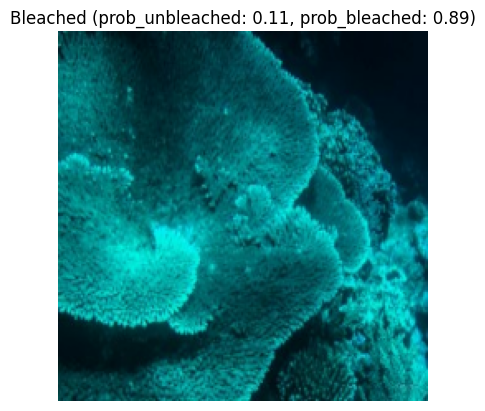

In [10]:
# Alternatively, make predictions on a batch of images from the test dataset

#Displaying predicstions vs true labels for 1 batch in test_set
for images, labels in test_ds.take(1):
    preds = model_loaded.predict(images)
    # Convert tensors to arrays
    true_labels = labels.numpy().astype(int).reshape(-1)
    pred_labels = (preds > 0.5).astype(int).reshape(-1)
    probs = preds.reshape(-1) # flattent to 1D
    break
# Map numeric labels → class names
class_names = test_ds.class_names
true_class_names = [class_names[i] for i in true_labels]
pred_class_names = [class_names[i] for i in pred_labels]
print("True classes:", true_class_names)
print("Predicted classes:", pred_class_names)


#Displaying one image with readable class names
import matplotlib.pyplot as plt
i = 11  # choose image index
pred_class_name = class_names[pred_labels[i]]
prob_unbleached = float(preds[i])
prob_bleached = 1 - prob_unbleached
plt.imshow(images[i].numpy().astype("uint8"))
plt.title(f"{pred_class_name} (prob_unbleached: {prob_unbleached:.2f}, prob_bleached: {prob_bleached:.2f})")
plt.axis("off")
plt.show()